In [31]:
!pip install statsmodels

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette(["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"])

print("📊 MUMBAI HOUSE PRICES ANALYSIS PROJECT")
print("=" * 50)

📊 MUMBAI HOUSE PRICES ANALYSIS PROJECT


In [33]:
df = pd.read_csv('/content/drive/MyDrive/Machine Learning/Mumbai House Prices.csv')

In [34]:
print("🔍 INITIAL DATA EXPLORATION")
print("=" * 40)

# Basic Information about dataset
print(f"Dataset shape : {df.shape}")
print(f"Dataset rows : {df.shape[0]}")
print(f"Dataset columns : {df.shape[1]}")
print("\nNumber of Columns")
print(df.columns.tolist())
print("\n" + "=" * 40)

# Display first 5 rows
print(df.head())
print("\n" + "=" * 40)


# Display table information
print("Data Types and their info")
print(df.info())
print("\n" + "=" * 40)

# Display basic statistics
print("Basic Statistics")
print(df.describe())
print("\n" + "=" * 40)

🔍 INITIAL DATA EXPLORATION
Dataset shape : (76038, 9)
Dataset rows : 76038
Dataset columns : 9

Number of Columns
['bhk', 'type', 'locality', 'area', 'price', 'price_unit', 'region', 'status', 'age']

   bhk       type                              locality  area  price  \
0    3  Apartment   Lak And Hanware The Residency Tower   685   2.50   
1    2  Apartment     Radheya Sai Enclave Building No 2   640  52.51   
2    2  Apartment                         Romell Serene   610   1.73   
3    2  Apartment  Soundlines Codename Urban Rainforest   876  59.98   
4    2  Apartment                         Origin Oriana   659  94.11   

  price_unit          region              status  age  
0         Cr    Andheri West       Ready to move  New  
1          L    Naigaon East  Under Construction  New  
2         Cr   Borivali West  Under Construction  New  
3          L          Panvel  Under Construction  New  
4          L  Mira Road East  Under Construction  New  

Data Types and their info
<cl

In [35]:
print("🧹 DATA CLEANING AND PREPROCESSING")
print("=" * 40)

# Check for missing values
print(df.isnull().sum())
print("\n" + "=" * 40)

# Check for duplicates
print(f"Number of duplicates : {df.duplicated().sum()}")
print("\n" + "=" * 40)

# Remove duplicates if any
df_clean = df.drop_duplicates()
print(f"Shape after removing duplicates : {df_clean.shape}")


# Check unique value in categorical columns
categorical_cols = ['type','locality','price_unit','region','status','age']
print("\nUnique values in categorical columns")
for col in categorical_cols:
    print(f"{col} : {df_clean[col].nunique()} unique values")
print("=" * 40)

# Handle price_unit column - convert all prices to a common unit (Lakhs)
print("Standardizing Price Units...")

def standardize_price(row):
    """
    Convert all prices to Lakhs for consistency
    Cr (Crore) = 100 Lakhs
    """
    if row['price_unit'] == 'Cr':
        return row['price'] * 100  # Convert Crore to Lakhs
    else:  # 'L' for Lakhs
        return row['price']

# Apply standardization
df_clean['price_lakhs'] = df_clean.apply(standardize_price, axis=1)
print("Price standardization completed!")
print("\n" + "="*40)

# Create price per sqft feature
df_clean['price_per_sqft'] = df_clean['price_lakhs'] / df_clean['area']
print("Price per sqft feature created!")
print("\n" + "="*40)

# Check for outliers in numerical columns
numerical_cols = ['bhk', 'area', 'price_lakhs', 'price_per_sqft']
print("Outlier Analysis (using IQR method):")

for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df_clean)*100:.2f}%)")
print("\n" + "="*40)

🧹 DATA CLEANING AND PREPROCESSING
bhk           0
type          0
locality      0
area          0
price         0
price_unit    0
region        0
status        0
age           0
dtype: int64

Number of duplicates : 20312

Shape after removing duplicates : (55726, 9)

Unique values in categorical columns
type : 5 unique values
locality : 9782 unique values
price_unit : 2 unique values
region : 228 unique values
status : 2 unique values
age : 3 unique values
Standardizing Price Units...
Price standardization completed!

Price per sqft feature created!

Outlier Analysis (using IQR method):
bhk: 2659 outliers (4.77%)
area: 2856 outliers (5.13%)
price_lakhs: 4227 outliers (7.59%)
price_per_sqft: 1981 outliers (3.55%)



📈 EXPLORATORY DATA ANALYSIS (EDA)


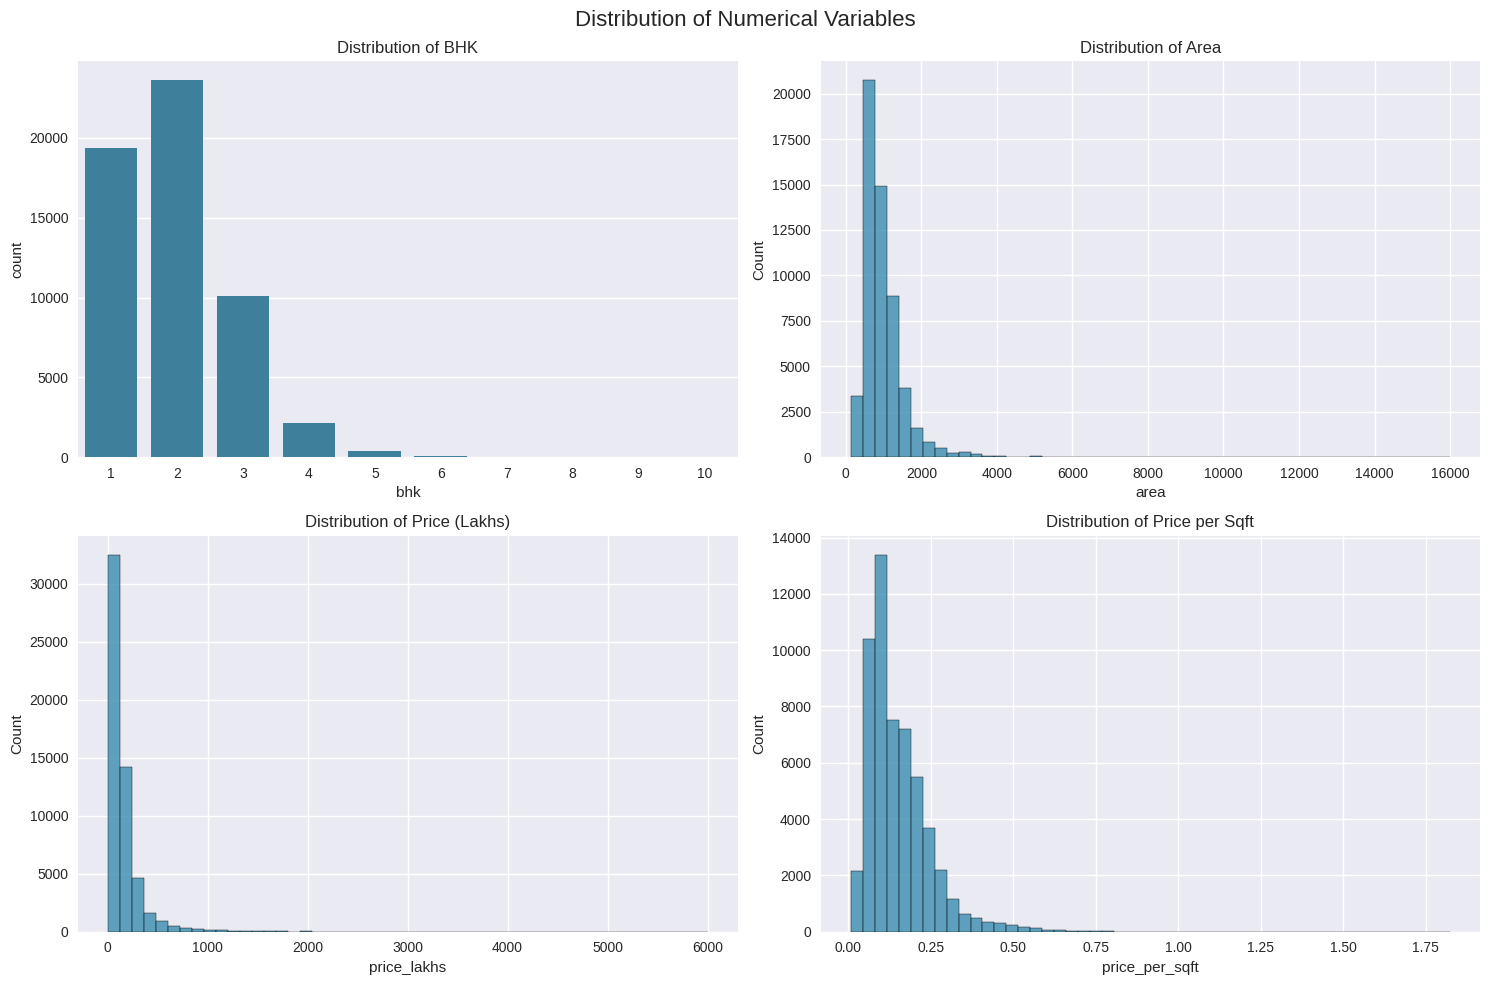

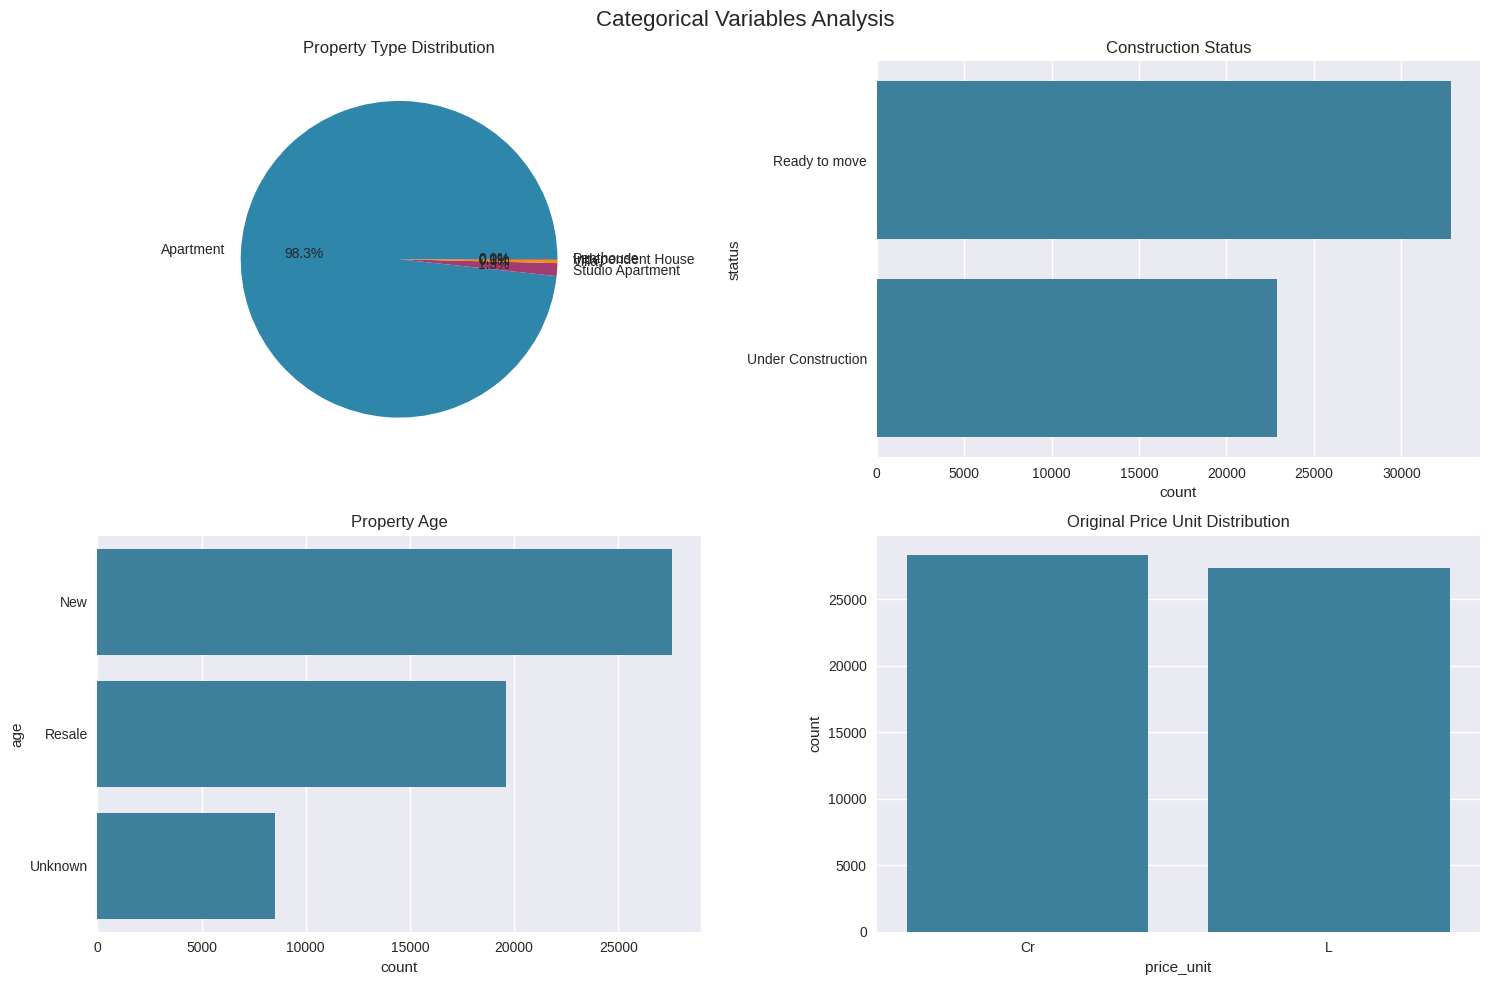

In [36]:
print("📈 EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 40)

# Distribution of numerical variables
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Numerical Variables', fontsize=16)

# BHK distribution
sns.countplot(data=df_clean, x='bhk', ax=axes[0,0])
axes[0,0].set_title('Distribution of BHK')

# Area distribution
sns.histplot(data=df_clean, x='area', bins=50, ax=axes[0,1])
axes[0,1].set_title('Distribution of Area')

# Price distribution
sns.histplot(data=df_clean, x='price_lakhs', bins=50, ax=axes[1,0])
axes[1,0].set_title('Distribution of Price (Lakhs)')

# Price per sqft distribution
sns.histplot(data=df_clean, x='price_per_sqft', bins=50, ax=axes[1,1])
axes[1,1].set_title('Distribution of Price per Sqft')

plt.tight_layout()
plt.show()

# Categorical variables analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Categorical Variables Analysis', fontsize=16)

# Property type distribution
type_counts = df_clean['type'].value_counts()
axes[0,0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%')
axes[0,0].set_title('Property Type Distribution')

# Status distribution
sns.countplot(data=df_clean, y='status', ax=axes[0,1])
axes[0,1].set_title('Construction Status')

# Age distribution
sns.countplot(data=df_clean, y='age', ax=axes[1,0])
axes[1,0].set_title('Property Age')

# Price unit distribution (original)
sns.countplot(data=df_clean, x='price_unit', ax=axes[1,1])
axes[1,1].set_title('Original Price Unit Distribution')

plt.tight_layout()
plt.show()

In [37]:
print("🔧 ADVANCED PANDAS OPERATIONS")
print("=" * 40)

# GROUP BY OPERATIONS
print("GROUP BY ANALYSIS:")
print("=" * 20)

# Average price by BHK
bhk_price = df_clean.groupby('bhk').agg({
    'price_lakhs': ['mean', 'median', 'std', 'count'],
    'area': 'mean',
    'price_per_sqft': 'mean'
}).round(2)
print("Price Analysis by BHK:")
print(bhk_price)
print("\n" + "="*20)

# Average price by property type and status
type_status_price = df_clean.groupby(['type', 'status']).agg({
    'price_lakhs': ['mean', 'median', 'count'],
    'area': 'mean',
    'price_per_sqft': 'mean'
}).round(2)
print("Price Analysis by Type and Status:")
print(type_status_price)
print("\n" + "="*20)

# Top 10 localities by average price
top_localities = df_clean.groupby('locality').agg({
    'price_lakhs': 'mean',
    'area': 'mean',
    'price_per_sqft': 'mean',
    'bhk': 'count'
}).round(2).nlargest(10, 'price_lakhs')
print("Top 10 Localities by Average Price:")
print(top_localities)
print("\n" + "="*20)

# MELT FUNCTION EXAMPLE
print("MELT FUNCTION EXAMPLE:")
print("=" * 20)

# Create a subset for melting
melt_subset = df_clean[['bhk', 'area', 'price_lakhs', 'price_per_sqft']].head(10)
melted_df = pd.melt(melt_subset, id_vars=['bhk'],
                   value_vars=['area', 'price_lakhs', 'price_per_sqft'],
                   var_name='metric', value_name='value')
print("Melted DataFrame (first 10 rows):")
print(melted_df.head(10))
print("\n" + "="*20)

# FILTERING OPERATIONS
print("FILTERING EXAMPLES:")
print("=" * 20)

# Filter properties in specific price range
mid_range_properties = df_clean[(df_clean['price_lakhs'] >= 50) & (df_clean['price_lakhs'] <= 100)]
print(f"Properties in 50-100 Lakhs range: {len(mid_range_properties)}")

# Filter ready to move properties in prime locations
prime_locations = ['Andheri West', 'Bandra West', 'Powai', 'Lower Parel']
ready_prime = df_clean[(df_clean['status'] == 'Ready to move') &
                      (df_clean['region'].isin(prime_locations))]
print(f"Ready to move properties in prime locations: {len(ready_prime)}")

# Filter new construction apartments
new_apartments = df_clean[(df_clean['type'] == 'Apartment') &
                         (df_clean['age'] == 'New') &
                         (df_clean['status'] == 'Under Construction')]
print(f"New under-construction apartments: {len(new_apartments)}")
print("\n" + "="*20)

🔧 ADVANCED PANDAS OPERATIONS
GROUP BY ANALYSIS:
Price Analysis by BHK:
    price_lakhs                              area price_per_sqft
           mean  median      std  count      mean           mean
bhk                                                             
1         62.90    58.0    36.77  19349    593.98           0.11
2        132.69   115.0    78.82  23609    930.36           0.15
3        282.39   240.0   200.68  10109   1423.24           0.20
4        603.89   470.0   436.28   2165   2358.81           0.25
5       1131.88   800.0   917.53    370   3772.77           0.29
6       1191.52   952.0   885.98     92   3916.14           0.29
7       1770.92  1500.0  1267.81     13   5556.38           0.31
8       2460.62  2600.0  1337.26      8   6085.62           0.39
9       3062.60  3000.0   493.05      5   6670.00           0.46
10      4150.00  4050.0   723.19      6  11366.67           0.42

Price Analysis by Type and Status:
                                     price_lakhs

In [38]:
print("⚙️ FEATURE ENGINEERING")
print("=" * 40)

# Create price categories
def price_category(price):
    if price < 50:
        return 'Budget (<50L)'
    elif price < 100:
        return 'Mid-Range (50L-1Cr)'
    elif price < 200:
        return 'Premium (1-2Cr)'
    else:
        return 'Luxury (>2Cr)'

df_clean['price_category'] = df_clean['price_lakhs'].apply(price_category)
print("Price categories created!")

# Create area categories
def area_category(area):
    if area < 500:
        return 'Compact (<500)'
    elif area < 800:
        return 'Medium (500-800)'
    elif area < 1200:
        return 'Large (800-1200)'
    else:
        return 'Very Large (>1200)'

df_clean['area_category'] = df_clean['area'].apply(area_category)
print("Area categories created!")

# Create region type based on price per sqft
region_avg_pps = df_clean.groupby('region')['price_per_sqft'].mean().sort_values(ascending=False)
high_end_regions = region_avg_pps.head(10).index
mid_end_regions = region_avg_pps.iloc[10:30].index

def region_type(region):
    if region in high_end_regions:
        return 'High-End'
    elif region in mid_end_regions:
        return 'Mid-Range'
    else:
        return 'Affordable'

df_clean['region_type'] = df_clean['region'].apply(region_type)
print("Region types created!")

# Display new features
print("\nNew Features Summary:")
print(f"Price Categories: {df_clean['price_category'].value_counts().to_dict()}")
print(f"Area Categories: {df_clean['area_category'].value_counts().to_dict()}")
print(f"Region Types: {df_clean['region_type'].value_counts().to_dict()}")
print("\n" + "="*40)

⚙️ FEATURE ENGINEERING
Price categories created!
Area categories created!
Region types created!

New Features Summary:
Price Categories: {'Mid-Range (50L-1Cr)': 18101, 'Premium (1-2Cr)': 15951, 'Luxury (>2Cr)': 12412, 'Budget (<50L)': 9262}
Area Categories: {'Medium (500-800)': 20433, 'Large (800-1200)': 17929, 'Very Large (>1200)': 12330, 'Compact (<500)': 5034}
Region Types: {'Affordable': 53443, 'Mid-Range': 1754, 'High-End': 529}



In [41]:
print("📋 RESAMPLING AND AGGREGATION")
print("=" * 40)

# Since we don't have datetime, we'll create bins for area and resample
# Create area bins for resampling-like operation
area_bins = pd.cut(df_clean['area'], bins=20)
resampled_data = df_clean.groupby(area_bins).agg({
    'price_lakhs': ['mean', 'median', 'std', 'count'],
    'price_per_sqft': 'mean',
    'bhk': 'mean'
}).round(2)

print("Resampled Data by Area Bins:")
print(resampled_data.head(10))
print("\n" + "="*20)

# Price analysis by price categories
price_cat_analysis = df_clean.groupby('price_category').agg({
    'bhk': ['mean', 'median'],
    'area': ['mean', 'median'],
    'price_per_sqft': ['mean', 'median'],
    'locality': 'nunique'
}).round(2)

print("Analysis by Price Categories:")
print(price_cat_analysis)
print("\n" + "="*20)

# Cross tabulation
cross_tab = pd.crosstab(df_clean['bhk'], df_clean['price_category'],
                       values=df_clean['price_lakhs'], aggfunc='mean')
print("Cross Tabulation: Average Price by BHK and Price Category:")
print(cross_tab.round(2))
print("\n" + "="*20)

📋 RESAMPLING AND AGGREGATION
Resampled Data by Area Bins:
                  price_lakhs                         price_per_sqft   bhk
                         mean  median      std  count           mean  mean
area                                                                      
(111.127, 920.65]       86.73    69.5    59.38  30685           0.13  1.40
(920.65, 1714.3]       187.21   151.0   132.48  21013           0.15  2.40
(1714.3, 2507.95]      451.51   360.0   288.02   2785           0.22  3.40
(2507.95, 3301.6]      740.94   624.5   433.38    704           0.26  4.06
(3301.6, 4095.25]      995.45   825.0   614.34    249           0.27  4.37
(4095.25, 4888.9]     1279.43  1099.5   733.69     92           0.29  4.59
(4888.9, 5682.55]     1293.31  1090.0   749.68     87           0.25  4.63
(5682.55, 6476.2]     2006.05  2225.0  1166.19     40           0.33  5.18
(6476.2, 7269.85]     2414.71  2000.0  1423.93     34           0.36  5.32
(7269.85, 8063.5]     2505.20  2200.0  115

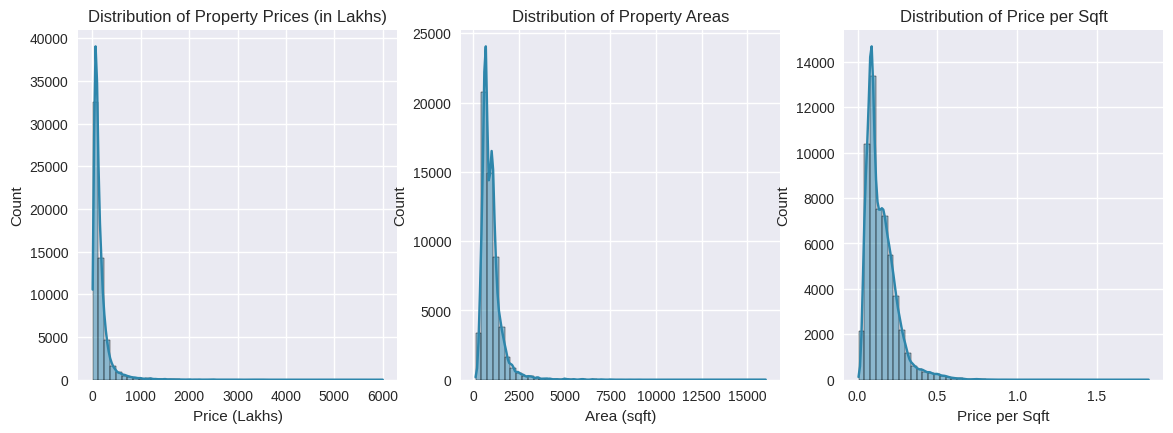

In [46]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
sns.histplot(df_clean['price_lakhs'], bins=50, kde=True)
plt.title('Distribution of Property Prices (in Lakhs)')
plt.xlabel('Price (Lakhs)')

plt.subplot(2, 3, 2)
sns.histplot(df_clean['area'], bins=50, kde=True)
plt.title('Distribution of Property Areas')
plt.xlabel('Area (sqft)')

plt.subplot(2, 3, 3)
sns.histplot(df_clean['price_per_sqft'], bins=50, kde=True)
plt.title('Distribution of Price per Sqft')
plt.xlabel('Price per Sqft')
plt.show()

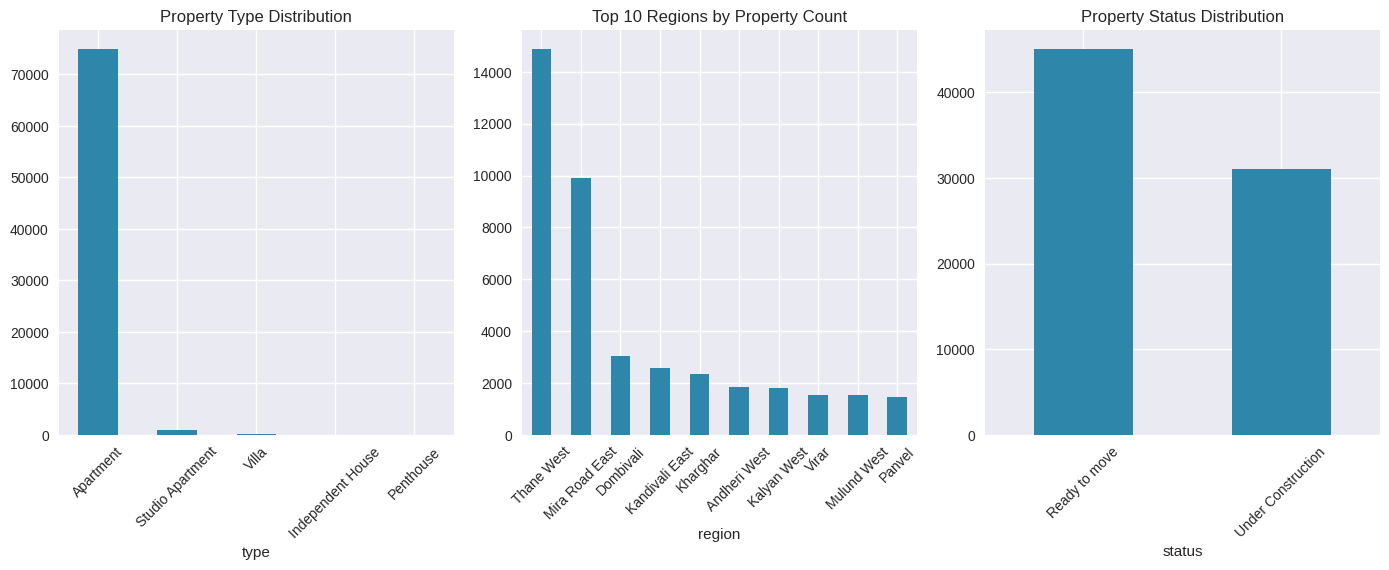

In [48]:
# 2. Categorical Variables Analysis
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 4)
df['type'].value_counts().plot(kind='bar')
plt.title('Property Type Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 5)
df['region'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Regions by Property Count')
plt.xticks(rotation=45)

plt.subplot(2, 3, 6)
df['status'].value_counts().plot(kind='bar')
plt.title('Property Status Distribution')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()